F1 Data Analytics
PARTE II: Monte Carlo Simulation
Autor: Gracia Nogales — Senior Advanced Support Engineer, Oracle
Datos: FastF1 · Bahrain GP 2023 (Race)

In [1]:
# ============================================================
# Análisis Avanzado de Datos de Telemetría F1
# Autor: Gracia Nogales — Senior Advanced Support Engineer, Oracle
# ============================================================

# ─────────────────────────────────────────────────────────────
# INSTALACIÓN 
# pip install fastf1 pandas numpy matplotlib plotly seaborn scipy
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.stats import linregress
from scipy.optimize import curve_fit

# ──────────────────────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ──────────────────────────────────────────────────────────────
fastf1.Cache.enable_cache('./f1_cache')
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

RACE_YEAR   = 2023
RACE_NAME   = 'Bahrain'
SESSION_TYPE = 'R'   # R = Race, Q = Qualifying

# Colores corporativos de la demo
COLOR_DRIVER1 = '#E8002D'   # Rojo (ej: Ferrari / Leclerc)
COLOR_DRIVER2 = '#00D2BE'   # Turquesa (ej: Mercedes / Hamilton)
COLOR_ACCENT  = '#FF8700'   # Naranja highlight
BG_COLOR      = '#1a1a2e'
GRID_COLOR    = '#2a2a4e'

print("=" * 60)
print("  F1 — DEMO TÉCNICA")
print("  Análisis Avanzado de Datos de Telemetría")
print("=" * 60)

# ──────────────────────────────────────────────────────────────


  F1 — DEMO TÉCNICA
  Análisis Avanzado de Datos de Telemetría


In [20]:
# SECCIÓN 1: CARGA DE DATOS
# ──────────────────────────────────────────────────────────────
print(f"\n[1/6] Cargando sesión: {RACE_YEAR} {RACE_NAME} Grand Prix...")

session = fastf1.get_session(RACE_YEAR, RACE_NAME, SESSION_TYPE)
session.load()

print(f"      Piloto 1 disponible: {session.drivers}")
print(f"      Circuito: {session.event['EventName']}")
print(f"      Fecha: {session.event['EventDate']}")

# Seleccionar pilotos para comparación
drivers = session.drivers
print(f"\n      Pilotos en sesión: {[session.get_driver(d)['Abbreviation'] for d in drivers[:10]]}")

DRIVER1 = 'VER'  # Verstappen
DRIVER2 = 'LEC'  # Leclerc

print(f"\n      Pilotos seleccionados para análisis: {DRIVER1} vs {DRIVER2}")

# ──────────────────────────────────────────────────────────────



[1/6] Cargando sesión: 2023 Bahrain Grand Prix...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


      Piloto 1 disponible: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
      Circuito: Bahrain Grand Prix
      Fecha: 2023-03-05 00:00:00

      Pilotos en sesión: ['VER', 'PER', 'ALO', 'SAI', 'HAM', 'STR', 'RUS', 'BOT', 'GAS', 'ALB']

      Pilotos seleccionados para análisis: VER vs LEC


In [21]:
# SECCIÓN 2: ANÁLISIS DE LA VUELTA RÁPIDA
# ──────────────────────────────────────────────────────────────
print(f"\n[2/6] Analizando vueltas rápidas...")

lap_d1 = session.laps.pick_driver(DRIVER1).pick_fastest()
lap_d2 = session.laps.pick_driver(DRIVER2).pick_fastest()

tel_d1 = lap_d1.get_car_data().add_distance()
tel_d2 = lap_d2.get_car_data().add_distance()

print(f"      {DRIVER1} fastest lap: {lap_d1['LapTime']}")
print(f"      {DRIVER2} fastest lap: {lap_d2['LapTime']}")
print(f"      Diferencia: {lap_d1['LapTime'] - lap_d2['LapTime']}")
print(f"      Puntos de datos {DRIVER1}: {len(tel_d1)}")
print(f"      Columnas disponibles: {list(tel_d1.columns)}")

# ──────────────────────────────────────────────────────────────



[2/6] Analizando vueltas rápidas...
      VER fastest lap: 0 days 00:01:36.236000
      LEC fastest lap: 0 days 00:01:37.170000
      Diferencia: -1 days +23:59:59.066000
      Puntos de datos VER: 352
      Columnas disponibles: ['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Time', 'SessionTime', 'Distance']



      Generando Speed Trace...


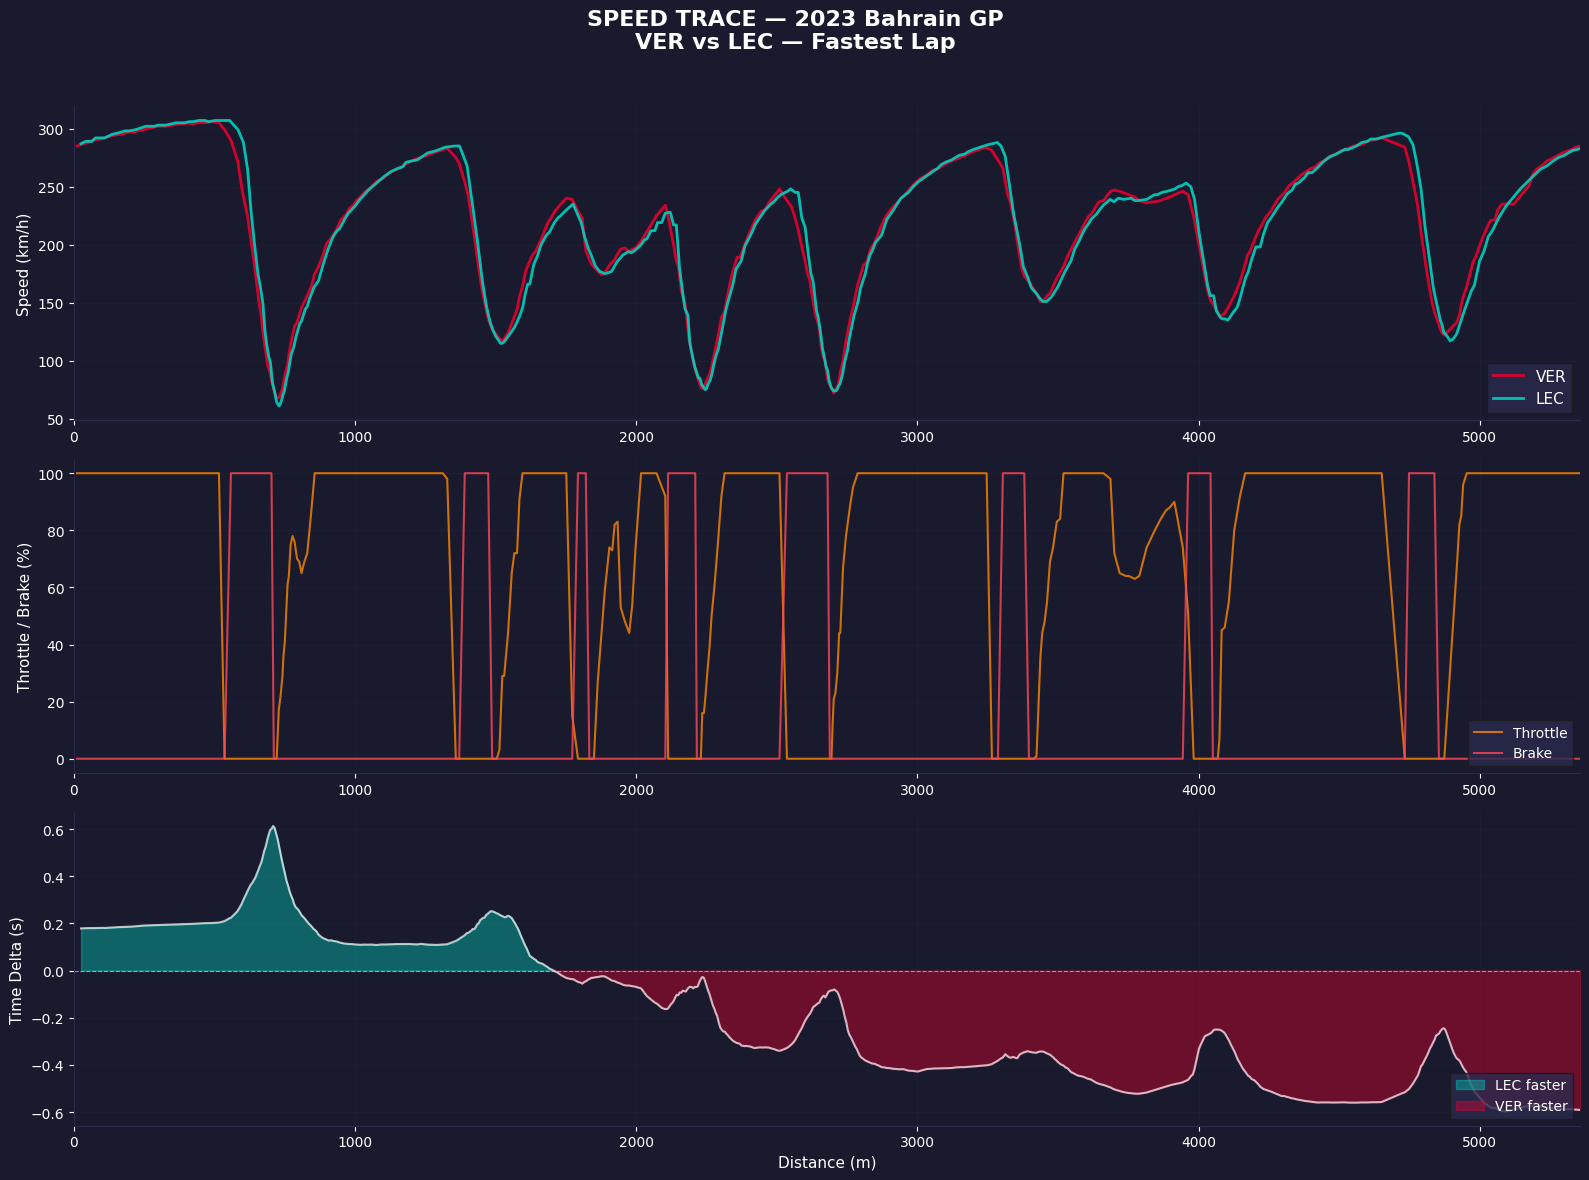

      [OK] Gráfico guardado: 01_speed_trace.png


In [22]:
# GRÁFICO 1: SPEED TRACE — El fingerprint de la vuelta
# ──────────────────────────────────────────────────────────────
print("\n      Generando Speed Trace...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor=BG_COLOR)
fig.suptitle(
    f'SPEED TRACE — {RACE_YEAR} {RACE_NAME} GP\n{DRIVER1} vs {DRIVER2} — Fastest Lap',
    color='white', fontsize=16, fontweight='bold', y=0.98
)

# Panel 1: Velocidad
ax1 = axes[0]
ax1.set_facecolor(BG_COLOR)
ax1.plot(tel_d1['Distance'], tel_d1['Speed'],
         color=COLOR_DRIVER1, linewidth=2, label=DRIVER1, alpha=0.9)
ax1.plot(tel_d2['Distance'], tel_d2['Speed'],
         color=COLOR_DRIVER2, linewidth=2, label=DRIVER2, alpha=0.9)
ax1.set_ylabel('Speed (km/h)', color='white', fontsize=11)
ax1.legend(loc='lower right', facecolor='#2a2a4e', labelcolor='white', fontsize=11)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color(GRID_COLOR)
ax1.spines['left'].set_color(GRID_COLOR)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.2, color=GRID_COLOR)
ax1.set_xlim(0, tel_d1['Distance'].max())

# Panel 2: Acelerador y Frenada
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
ax2.plot(tel_d1['Distance'], tel_d1['Throttle'],
         color=COLOR_ACCENT, linewidth=1.5, label='Throttle', alpha=0.8)
ax2.plot(tel_d1['Distance'], tel_d1['Brake'] * 100,
         color='#ff4757', linewidth=1.5, label='Brake', alpha=0.8)
ax2.set_ylabel('Throttle / Brake (%)', color='white', fontsize=11)
ax2.legend(loc='lower right', facecolor='#2a2a4e', labelcolor='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color(GRID_COLOR)
ax2.spines['left'].set_color(GRID_COLOR)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2, color=GRID_COLOR)
ax2.set_xlim(0, tel_d1['Distance'].max())
ax2.set_ylim(-5, 105)

# Panel 3: Delta de tiempo acumulado
ax3 = axes[2]
ax3.set_facecolor(BG_COLOR)

# Calcular delta interpolando sobre distancia común
from scipy.interpolate import interp1d

dist_common = np.linspace(
    max(tel_d1['Distance'].min(), tel_d2['Distance'].min()),
    min(tel_d1['Distance'].max(), tel_d2['Distance'].max()),
    1000
)

# Tiempo acumulado normalizado por distancia
time_d1 = tel_d1['SessionTime'].dt.total_seconds()
time_d2 = tel_d2['SessionTime'].dt.total_seconds()

interp_d1 = interp1d(tel_d1['Distance'], time_d1 - time_d1.iloc[0], fill_value='extrapolate')
interp_d2 = interp1d(tel_d2['Distance'], time_d2 - time_d2.iloc[0], fill_value='extrapolate')

delta = interp_d1(dist_common) - interp_d2(dist_common)

ax3.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.fill_between(dist_common, delta, 0,
                  where=(delta > 0), color=COLOR_DRIVER2, alpha=0.4, label=f'{DRIVER2} faster')
ax3.fill_between(dist_common, delta, 0,
                  where=(delta < 0), color=COLOR_DRIVER1, alpha=0.4, label=f'{DRIVER1} faster')
ax3.plot(dist_common, delta, color='white', linewidth=1.5, alpha=0.7)
ax3.set_ylabel('Time Delta (s)', color='white', fontsize=11)
ax3.set_xlabel('Distance (m)', color='white', fontsize=11)
ax3.legend(loc='lower right', facecolor='#2a2a4e', labelcolor='white', fontsize=10)
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color(GRID_COLOR)
ax3.spines['left'].set_color(GRID_COLOR)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(alpha=0.2, color=GRID_COLOR)
ax3.set_xlim(0, dist_common.max())

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('01_speed_trace.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("      [OK] Gráfico guardado: 01_speed_trace.png")

# ──────────────────────────────────────────────────────────────


In [23]:
# SECCIÓN 3: ANÁLISIS DE DEGRADACIÓN DE NEUMÁTICOS
# ──────────────────────────────────────────────────────────────
print(f"\n[3/6] Analizando degradación de neumáticos...")

def get_clean_laps(session, driver, min_pct_dist=0.95):
    """
    Extrae vueltas limpias de un piloto:
    - Excluye pit laps
    - Excluye vueltas bajo safety car
    - Excluye outlaps
    - Filtra vueltas completas
    """
    laps = session.laps.pick_driver(driver).copy()

    # Filtrar vueltas válidas
    laps = laps[
        laps['PitOutTime'].isna() &   # No outlap
        laps['PitInTime'].isna() &    # No inlap
        (laps['TrackStatus'] == '1')  # Pista verde
    ].copy()

    # Convertir LapTime a segundos
    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

    # Filtrar tiempos razonables (eliminar outliers extremos)
    median_lt = laps['LapTimeSeconds'].median()
    laps = laps[
        (laps['LapTimeSeconds'] > median_lt * 0.97) &
        (laps['LapTimeSeconds'] < median_lt * 1.05)
    ].copy()

    return laps


def model_degradation(tyre_age, a, b, c):
    """
    Modelo cuadrático de degradación de neumático.
    LapTime = a + b*age + c*age²
    """
    return a + b * tyre_age + c * tyre_age**2


laps_d1 = get_clean_laps(session, DRIVER1)
laps_d2 = get_clean_laps(session, DRIVER2)

print(f"      Vueltas limpias {DRIVER1}: {len(laps_d1)}")
print(f"      Vueltas limpias {DRIVER2}: {len(laps_d2)}")

# Análisis por stint y compuesto
compounds_d1 = laps_d1['Compound'].unique()
compounds_d2 = laps_d2['Compound'].unique()
print(f"      Compuestos {DRIVER1}: {compounds_d1}")
print(f"      Compuestos {DRIVER2}: {compounds_d2}")

# ──────────────────────────────────────────────────────────────



[3/6] Analizando degradación de neumáticos...
      Vueltas limpias VER: 49
      Vueltas limpias LEC: 33
      Compuestos VER: ['SOFT' 'HARD']
      Compuestos LEC: ['SOFT' 'HARD']


      Generando gráfico de degradación...


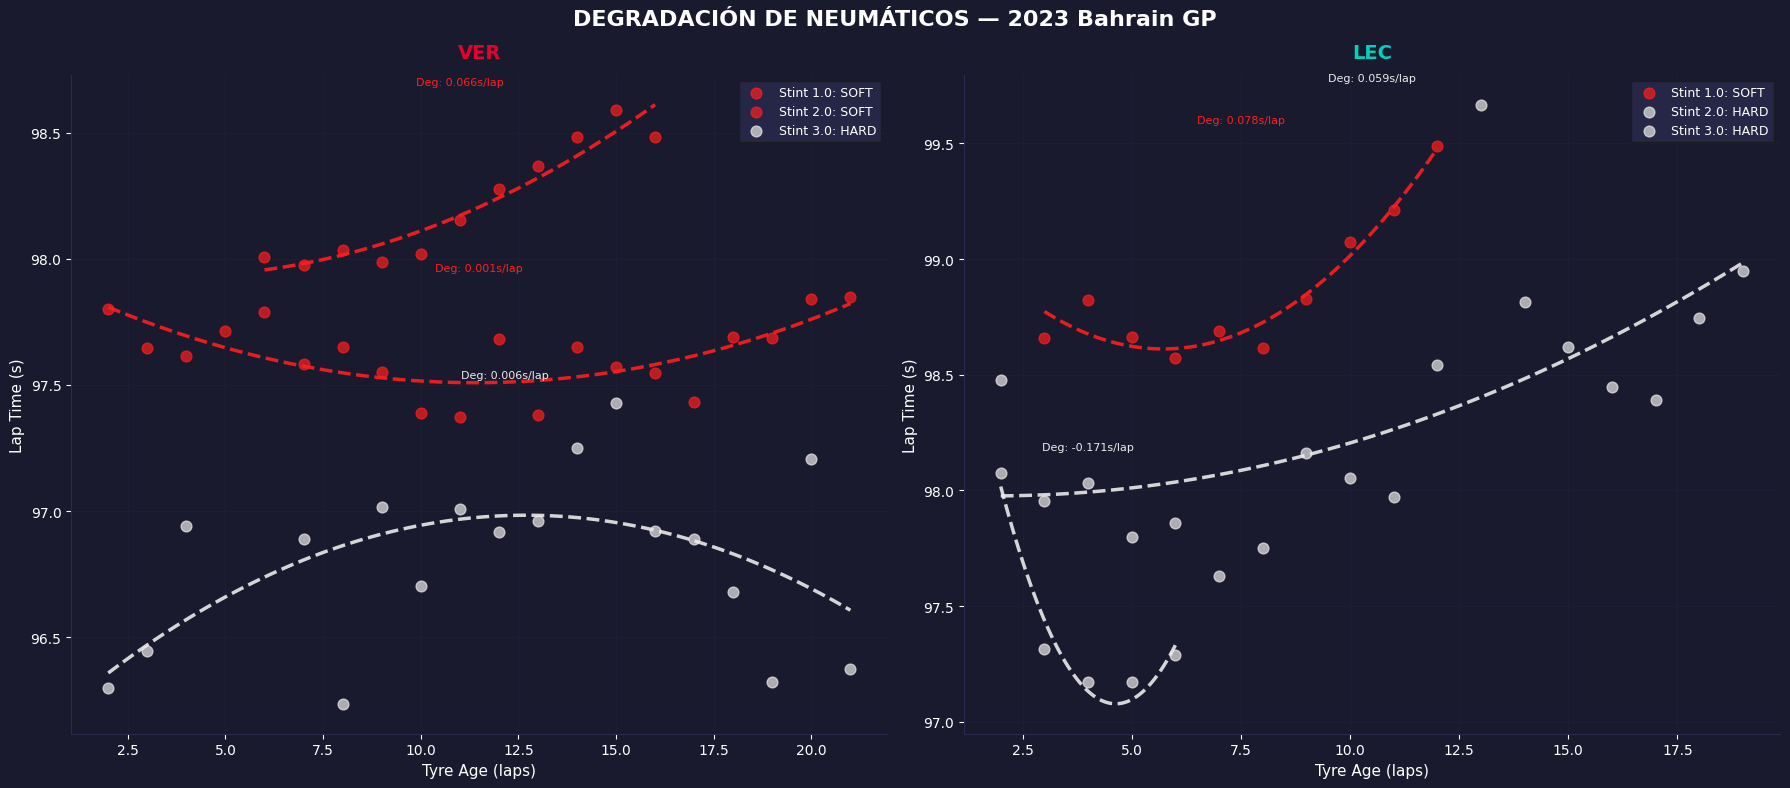

      [OK] Gráfico guardado: 02_tyre_degradation.png


In [24]:
# GRÁFICO 2: DEGRADACIÓN DE NEUMÁTICOS
# ──────────────────────────────────────────────────────────────
print("      Generando gráfico de degradación...")

compound_colors = {
    'SOFT': '#FF1E1E',
    'MEDIUM': '#FFC906',
    'HARD': '#EBEBEB',
    'INTERMEDIATE': '#39B54A',
    'WET': '#0067FF'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG_COLOR)
fig.suptitle(
    f'DEGRADACIÓN DE NEUMÁTICOS — {RACE_YEAR} {RACE_NAME} GP',
    color='white', fontsize=16, fontweight='bold'
)

for ax, driver, laps, driver_color in [
    (axes[0], DRIVER1, laps_d1, COLOR_DRIVER1),
    (axes[1], DRIVER2, laps_d2, COLOR_DRIVER2)
]:
    ax.set_facecolor(BG_COLOR)
    ax.set_title(f'{driver}', color=driver_color, fontsize=14, fontweight='bold')

    for stint_num in laps['Stint'].unique():
        stint_laps = laps[laps['Stint'] == stint_num].copy()
        if len(stint_laps) < 3:
            continue

        compound = stint_laps['Compound'].iloc[0]
        color = compound_colors.get(compound, '#FFFFFF')

        # Datos del stint
        age = stint_laps['TyreLife'].values.astype(float)
        lap_times = stint_laps['LapTimeSeconds'].values

        # Scatter plot
        ax.scatter(age, lap_times, color=color, alpha=0.7, s=60, zorder=3,
                   label=f"Stint {stint_num}: {compound}")

        # Ajuste del modelo de degradación (si hay suficientes puntos)
        if len(age) >= 4:
            try:
                popt, _ = curve_fit(model_degradation, age, lap_times,
                                    p0=[lap_times.min(), 0.05, 0.001],
                                    maxfev=5000)
                age_fit = np.linspace(age.min(), age.max(), 100)
                lt_fit = model_degradation(age_fit, *popt)
                ax.plot(age_fit, lt_fit, color=color, linewidth=2.5,
                        linestyle='--', alpha=0.9)

                # Mostrar tasa de degradación
                deg_rate = popt[1] + 2 * popt[2] * age.mean()
                ax.text(age.mean(), lap_times.max() + 0.1,
                        f'Deg: {deg_rate:.3f}s/lap',
                        color=color, fontsize=8, ha='center')
            except Exception:
                pass

    ax.set_xlabel('Tyre Age (laps)', color='white', fontsize=11)
    ax.set_ylabel('Lap Time (s)', color='white', fontsize=11)
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color(GRID_COLOR)
    ax.spines['left'].set_color(GRID_COLOR)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2, color=GRID_COLOR)

    legend = ax.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('02_tyre_degradation.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("      [OK] Gráfico guardado: 02_tyre_degradation.png")

# ──────────────────────────────────────────────────────────────



[4/6] Analizando evolución del ritmo de carrera...


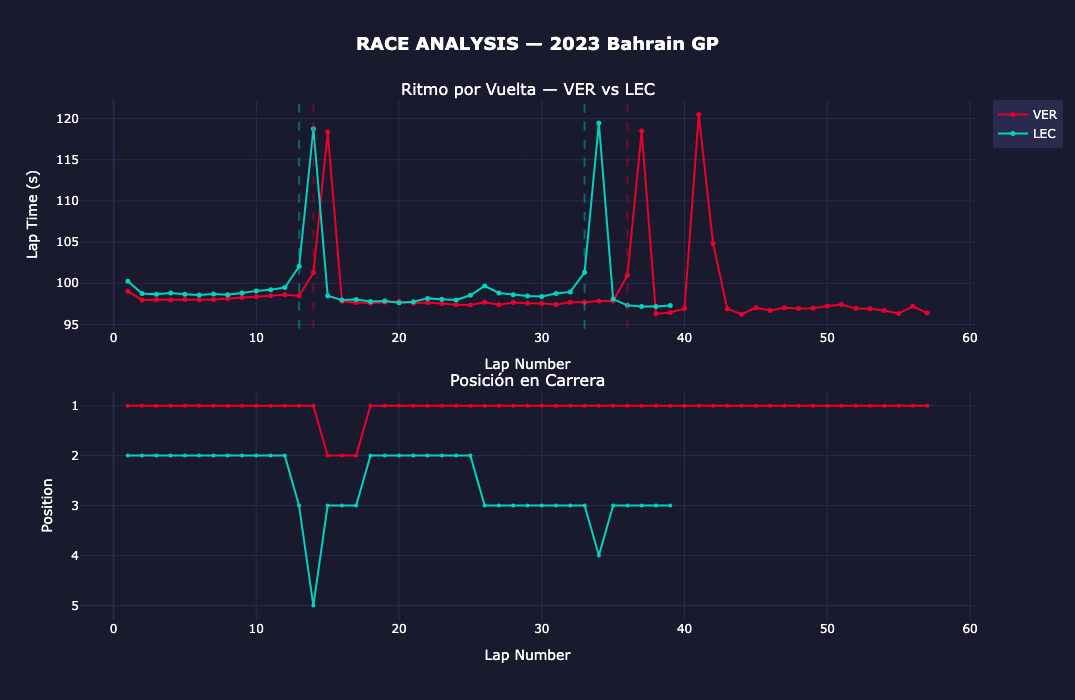

      [OK] Gráfico guardado: 03_race_analysis.html


In [25]:
# SECCIÓN 4: EVOLUCIÓN DEL RITMO DE CARRERA
# ──────────────────────────────────────────────────────────────
print(f"\n[4/6] Analizando evolución del ritmo de carrera...")

# ──────────────────────────────────────────────────────────────
# GRÁFICO 3: RITMO POR VUELTA — Comparación completa
# ──────────────────────────────────────────────────────────────

# Obtener todas las vueltas (con pit laps para contexto)
all_laps_d1 = session.laps.pick_driver(DRIVER1).copy()
all_laps_d2 = session.laps.pick_driver(DRIVER2).copy()

all_laps_d1['LapTimeSeconds'] = all_laps_d1['LapTime'].dt.total_seconds()
all_laps_d2['LapTimeSeconds'] = all_laps_d2['LapTime'].dt.total_seconds()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        f'Ritmo por Vuelta — {DRIVER1} vs {DRIVER2}',
        'Posición en Carrera'
    ],
    vertical_spacing=0.12
)

# Panel 1: Tiempo por vuelta
fig.add_trace(
    go.Scatter(
        x=all_laps_d1['LapNumber'],
        y=all_laps_d1['LapTimeSeconds'],
        mode='lines+markers',
        name=DRIVER1,
        line=dict(color=COLOR_DRIVER1, width=2),
        marker=dict(size=5),
        hovertemplate='<b>' + DRIVER1 + '</b><br>Vuelta: %{x}<br>Tiempo: %{y:.3f}s<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=all_laps_d2['LapNumber'],
        y=all_laps_d2['LapTimeSeconds'],
        mode='lines+markers',
        name=DRIVER2,
        line=dict(color=COLOR_DRIVER2, width=2),
        marker=dict(size=5),
        hovertemplate='<b>' + DRIVER2 + '</b><br>Vuelta: %{x}<br>Tiempo: %{y:.3f}s<extra></extra>'
    ),
    row=1, col=1
)

# Marcar pit stops
pit_laps_d1 = all_laps_d1[all_laps_d1['PitInTime'].notna()]['LapNumber']
pit_laps_d2 = all_laps_d2[all_laps_d2['PitInTime'].notna()]['LapNumber']

for pl in pit_laps_d1:
    fig.add_vline(x=pl, line_dash="dash", line_color=COLOR_DRIVER1,
                  opacity=0.4, row=1, col=1)

for pl in pit_laps_d2:
    fig.add_vline(x=pl, line_dash="dash", line_color=COLOR_DRIVER2,
                  opacity=0.4, row=1, col=1)

# Panel 2: Posición en carrera
fig.add_trace(
    go.Scatter(
        x=all_laps_d1['LapNumber'],
        y=all_laps_d1['Position'],
        mode='lines+markers',
        name=f'{DRIVER1} Pos',
        line=dict(color=COLOR_DRIVER1, width=2),
        marker=dict(size=4),
        showlegend=False
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=all_laps_d2['LapNumber'],
        y=all_laps_d2['Position'],
        mode='lines+markers',
        name=f'{DRIVER2} Pos',
        line=dict(color=COLOR_DRIVER2, width=2),
        marker=dict(size=4),
        showlegend=False
    ),
    row=2, col=1
)

fig.update_layout(
    height=700,
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=BG_COLOR,
    font=dict(color='white'),
    title=dict(
        text=f'<b>RACE ANALYSIS — {RACE_YEAR} {RACE_NAME} GP</b>',
        font=dict(size=18, color='white'),
        x=0.5
    ),
    legend=dict(bgcolor='#2a2a4e', bordercolor='#444466')
)

fig.update_xaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, title_text='Lap Number')
fig.update_yaxes(gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR)
fig.update_yaxes(autorange='reversed', row=2, col=1, title_text='Position')
fig.update_yaxes(title_text='Lap Time (s)', row=1, col=1)

fig.write_html('03_race_analysis.html')
fig.show()
print("      [OK] Gráfico guardado: 03_race_analysis.html")

# ──────────────────────────────────────────────────────────────



[5/6] Generando mapa de velocidad en circuito...


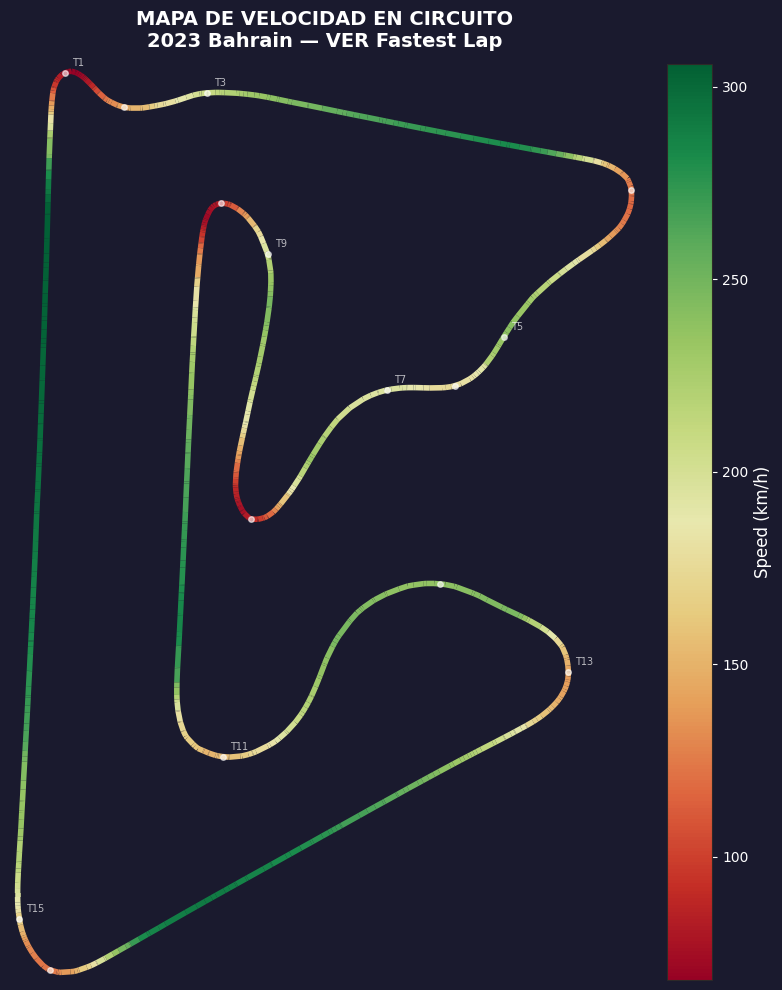

      [OK] Gráfico guardado: 04_speed_map.png


In [26]:
# SECCIÓN 5: MAPA DE VELOCIDAD EN EL CIRCUITO
# ──────────────────────────────────────────────────────────────
print(f"\n[5/6] Generando mapa de velocidad en circuito...")

lap_map = session.laps.pick_driver(DRIVER1).pick_fastest()
tel_map = lap_map.get_telemetry().add_distance()

# Obtener posición X, Y del circuito
x = tel_map['X'].values
y = tel_map['Y'].values
speed = tel_map['Speed'].values

# Normalizar velocidad para colormap
speed_norm = (speed - speed.min()) / (speed.max() - speed.min())

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Crear segmentos de línea coloreados por velocidad
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=speed.min(), vmax=speed.max())
lc = LineCollection(segments, cmap='RdYlGn', norm=norm, linewidth=4, alpha=0.9)
lc.set_array(speed)
ax.add_collection(lc)

# Colorbar
cbar = plt.colorbar(lc, ax=ax, pad=0.02)
cbar.set_label('Speed (km/h)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ax.set_xlim(x.min() - 100, x.max() + 100)
ax.set_ylim(y.min() - 100, y.max() + 100)
ax.set_aspect('equal')
ax.axis('off')

ax.set_title(
    f'MAPA DE VELOCIDAD EN CIRCUITO\n{RACE_YEAR} {RACE_NAME} — {DRIVER1} Fastest Lap',
    color='white', fontsize=14, fontweight='bold'
)

# Añadir puntos de inicio/fin de sectores si están disponibles
try:
    for i, corner in enumerate(session.get_circuit_info().corners.itertuples()):
        ax.plot(corner.X, corner.Y, 'o', color='white', markersize=4, alpha=0.6)
        if i % 2 == 0:
            ax.annotate(f'T{corner.Number}',
                        (corner.X, corner.Y),
                        color='white', fontsize=7, alpha=0.7,
                        xytext=(5, 5), textcoords='offset points')
except Exception:
    pass

plt.tight_layout()
plt.savefig('04_speed_map.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("      [OK] Gráfico guardado: 04_speed_map.png")

# ──────────────────────────────────────────────────────────────



[6/6] Ejecutando simulación de estrategia...
      Simulando 1 parada vs 2 paradas — Monte Carlo

      Ejecutando 50,000 simulaciones por estrategia...
      Circuito: Bahrain — 57 vueltas

  ──────────────────────────────────────────────────
  Estrategia: 1 Parada (Medium → Hard)
  ──────────────────────────────────────────────────
  Media:       5466.39s  (91.11 min)
  Mediana:     5464.44s
  Std Dev:     15.11s
  P10 (best):  5446.92s
  P90 (worst): 5486.46s
  Min:         5442.29s
  Max:         5547.11s

  ──────────────────────────────────────────────────
  Estrategia: 2 Paradas (Soft → Medium → Hard)
  ──────────────────────────────────────────────────
  Media:       5452.49s  (90.87 min)
  Mediana:     5450.72s
  Std Dev:     15.03s
  P10 (best):  5433.07s
  P90 (worst): 5472.46s
  Min:         5428.53s
  Max:         5538.55s

  ══════════════════════════════════════════════════
  VEREDICTO DE LA SIMULACIÓN:
  ══════════════════════════════════════════════════
  Diferencia d

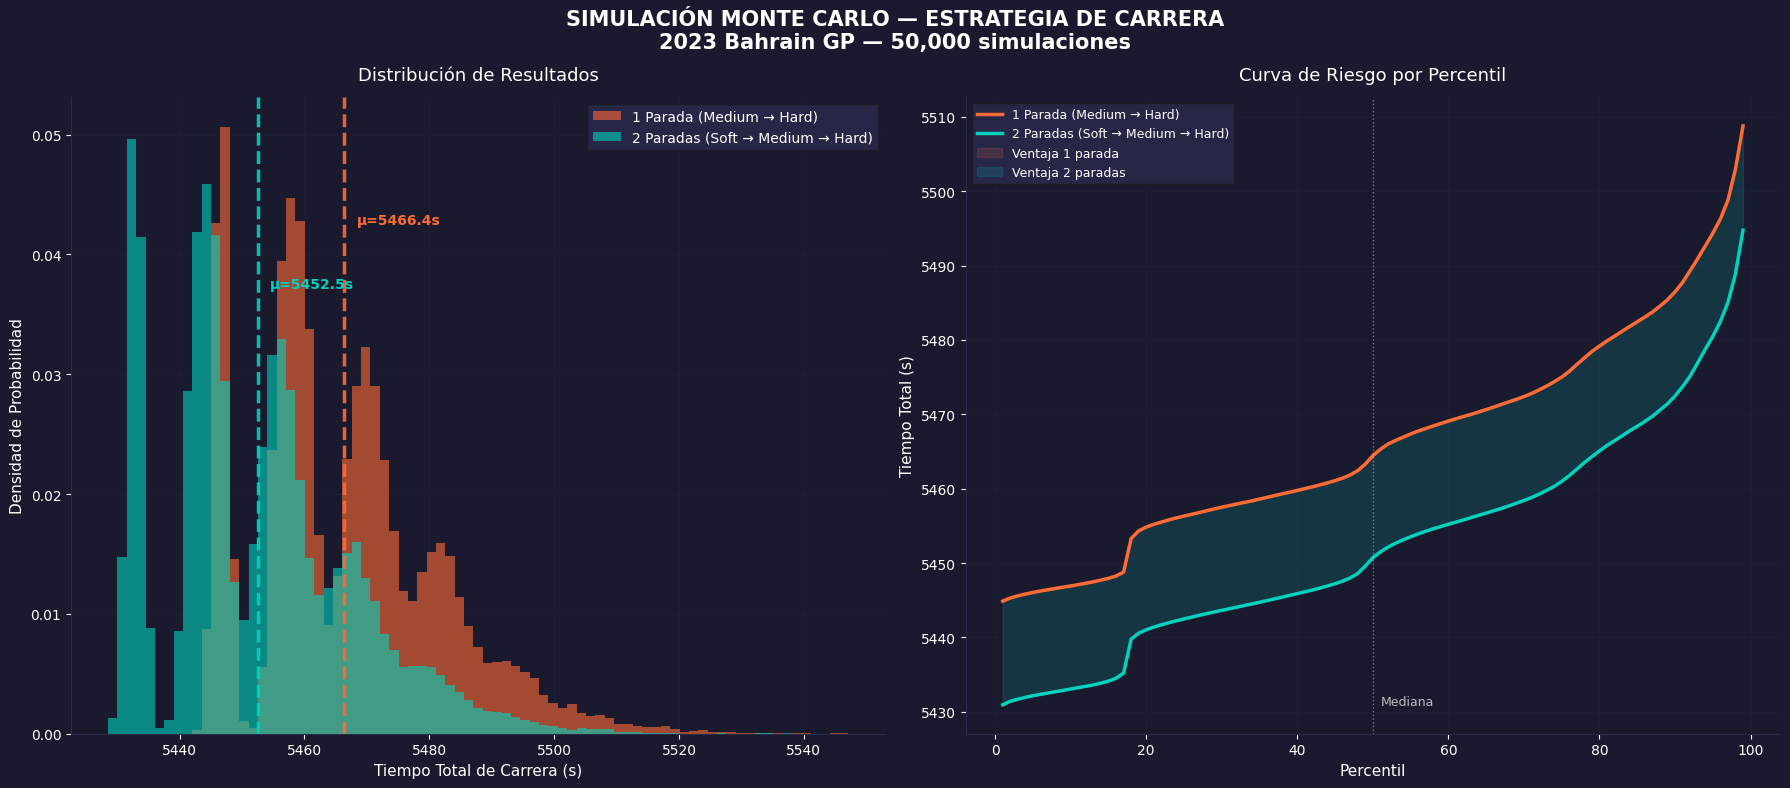

      [OK] Gráfico guardado: 05_strategy_simulation.png

  DEMO COMPLETADA — Todos los gráficos generados.
  Archivos:
    01_speed_trace.png
    02_tyre_degradation.png
    03_race_analysis.html  (interactivo)
    04_speed_map.png
    05_strategy_simulation.png


In [27]:
# SECCIÓN 6 (D): SIMULACIÓN DE ESTRATEGIA — Monte Carlo
# ──────────────────────────────────────────────────────────────
print(f"\n[6/6] Ejecutando simulación de estrategia...")
print("      Simulando 1 parada vs 2 paradas — Monte Carlo\n")


def simulate_race(
    total_laps: int,
    base_pace: float,
    pit_time_loss: float,
    strategy: list,
    compound_params: dict,
    safety_car_prob: float = 0.03,
    n_simulations: int = 10_000,
    seed: int = 42
) -> np.ndarray:
    """
    Simula una carrera de F1 con parámetros estocásticos.
 
    Parameters:
    -----------
    total_laps       : Número total de vueltas
    base_pace        : Tiempo base por vuelta (segundos)
    pit_time_loss    : Tiempo perdido por pit stop (segundos)
    strategy         : Lista de vueltas en que se hace pit stop
                       Ej: [28] para 1 parada, [20, 40] para 2 paradas
    compound_params  : Dict con parámetros de degradación por stint
                       Ej: {0: {'deg': 0.08, 'offset': 0.0}, 1: {'deg': 0.05, 'offset': 0.3}}
    safety_car_prob  : Probabilidad de Safety Car por vuelta
    n_simulations    : Número de iteraciones Monte Carlo
    seed             : Semilla para reproducibilidad
 
    Returns:
    --------
    np.ndarray: Array de tiempos totales por simulación
    """
    rng = np.random.default_rng(seed)
    total_times = np.zeros(n_simulations)

    for sim in range(n_simulations):
        total_time = 0.0
        stint = 0
        tyre_age = 0

        for lap in range(1, total_laps + 1):
            # Determinar parámetros del compuesto actual
            params = compound_params.get(stint, compound_params[max(compound_params.keys())])
            deg_rate = params['deg']
            offset = params['offset']

            # Tiempo de la vuelta base + degradación + ruido estocástico
            lap_noise = rng.normal(0, 0.15)  # ±0.15s variación aleatoria
            lap_time = (base_pace
                       + offset
                       + deg_rate * tyre_age
                       + 0.002 * tyre_age**2  # no-linealidad
                       + lap_noise)

            # Safety Car: ralentiza la vuelta entre 8-15 segundos
            if rng.random() < safety_car_prob:
                sc_delta = rng.uniform(8, 15)
                lap_time += sc_delta

            total_time += lap_time
            tyre_age += 1

            # Pit stop: resetear neumáticos y añadir tiempo de pit
            if lap in strategy:
                pit_noise = rng.normal(0, 0.3)  # variabilidad en el pit stop
                total_time += pit_time_loss + pit_noise
                stint += 1
                tyre_age = 0

        total_times[sim] = total_time

    return total_times


# ── Parámetros de la carrera ──────────────────────────────────
TOTAL_LAPS = 57        # Bahrain GP
BASE_PACE  = 93.5      # segundos por vuelta (ritmo base)
PIT_LOSS   = 22.0      # segundos perdidos en boxes (Bahrain)

# Parámetros de degradación por compuesto
# stint 0 = primer juego de neumáticos, stint 1 = segundo juego, etc.
STRATEGY_1STOP = {
    'name': '1 Parada (Medium → Hard)',
    'pit_laps': [25],
    'compounds': {
        0: {'deg': 0.09, 'offset': 0.0},   # Medium: degrada más
        1: {'deg': 0.05, 'offset': 0.4},   # Hard: más lento pero dura más
    },
    'color': '#FF6B35'
}

STRATEGY_2STOP = {
    'name': '2 Paradas (Soft → Medium → Hard)',
    'pit_laps': [18, 38],
    'compounds': {
        0: {'deg': 0.12, 'offset': -0.5},  # Soft: más rápido pero degrada fuerte
        1: {'deg': 0.08, 'offset': 0.2},   # Medium
        2: {'deg': 0.05, 'offset': 0.5},   # Hard
    },
    'color': '#00D2BE'
}

N_SIMULATIONS = 50_000

print(f"      Ejecutando {N_SIMULATIONS:,} simulaciones por estrategia...")
print(f"      Circuito: {RACE_NAME} — {TOTAL_LAPS} vueltas\n")

results_1stop = simulate_race(
    total_laps=TOTAL_LAPS,
    base_pace=BASE_PACE,
    pit_time_loss=PIT_LOSS,
    strategy=STRATEGY_1STOP['pit_laps'],
    compound_params=STRATEGY_1STOP['compounds'],
    n_simulations=N_SIMULATIONS,
    seed=42
)

results_2stop = simulate_race(
    total_laps=TOTAL_LAPS,
    base_pace=BASE_PACE,
    pit_time_loss=PIT_LOSS,
    strategy=STRATEGY_2STOP['pit_laps'],
    compound_params=STRATEGY_2STOP['compounds'],
    n_simulations=N_SIMULATIONS,
    seed=42
)

# ── Análisis estadístico de resultados ───────────────────────
for name, results in [(STRATEGY_1STOP['name'], results_1stop),
                       (STRATEGY_2STOP['name'], results_2stop)]:
    print(f"  {'─'*50}")
    print(f"  Estrategia: {name}")
    print(f"  {'─'*50}")
    print(f"  Media:       {results.mean():.2f}s  ({results.mean()/60:.2f} min)")
    print(f"  Mediana:     {np.median(results):.2f}s")
    print(f"  Std Dev:     {results.std():.2f}s")
    print(f"  P10 (best):  {np.percentile(results, 10):.2f}s")
    print(f"  P90 (worst): {np.percentile(results, 90):.2f}s")
    print(f"  Min:         {results.min():.2f}s")
    print(f"  Max:         {results.max():.2f}s")
    print()

diff_mean = results_1stop.mean() - results_2stop.mean()
win_rate_1stop = (results_1stop < results_2stop).mean() * 100
win_rate_2stop = (results_2stop < results_1stop).mean() * 100

print(f"  {'═'*50}")
print(f"  VEREDICTO DE LA SIMULACIÓN:")
print(f"  {'═'*50}")
print(f"  Diferencia de medias: {diff_mean:+.2f}s")
if diff_mean > 0:
    print(f"  → La estrategia de 2 paradas es más rápida en promedio")
    print(f"    en {abs(diff_mean):.2f} segundos.")
else:
    print(f"  → La estrategia de 1 parada es más rápida en promedio")
    print(f"    en {abs(diff_mean):.2f} segundos.")
print(f"  Prob. de ganar con 1 parada:  {win_rate_1stop:.1f}%")
print(f"  Prob. de ganar con 2 paradas: {win_rate_2stop:.1f}%")
print()

# ── GRÁFICO 4: Resultados de la simulación ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG_COLOR)
fig.suptitle(
    f'SIMULACIÓN MONTE CARLO — ESTRATEGIA DE CARRERA\n'
    f'{RACE_YEAR} {RACE_NAME} GP — {N_SIMULATIONS:,} simulaciones',
    color='white', fontsize=15, fontweight='bold'
)

# Panel 1: Histograma comparativo
ax1 = axes[0]
ax1.set_facecolor(BG_COLOR)

bins = np.linspace(
    min(results_1stop.min(), results_2stop.min()),
    max(results_1stop.max(), results_2stop.max()),
    80
)

ax1.hist(results_1stop, bins=bins, alpha=0.6,
         color=STRATEGY_1STOP['color'], label=STRATEGY_1STOP['name'],
         density=True, edgecolor='none')
ax1.hist(results_2stop, bins=bins, alpha=0.6,
         color=STRATEGY_2STOP['color'], label=STRATEGY_2STOP['name'],
         density=True, edgecolor='none')

# Líneas de media
ax1.axvline(results_1stop.mean(), color=STRATEGY_1STOP['color'],
            linewidth=2.5, linestyle='--', alpha=0.9)
ax1.axvline(results_2stop.mean(), color=STRATEGY_2STOP['color'],
            linewidth=2.5, linestyle='--', alpha=0.9)

ax1.set_xlabel('Tiempo Total de Carrera (s)', color='white', fontsize=11)
ax1.set_ylabel('Densidad de Probabilidad', color='white', fontsize=11)
ax1.set_title('Distribución de Resultados', color='white', fontsize=13)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color(GRID_COLOR)
ax1.spines['left'].set_color(GRID_COLOR)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.2, color=GRID_COLOR)
legend1 = ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=10)

# Anotaciones de media
ax1.text(results_1stop.mean() + 2, ax1.get_ylim()[1] * 0.8,
         f'μ={results_1stop.mean():.1f}s',
         color=STRATEGY_1STOP['color'], fontsize=10, fontweight='bold')
ax1.text(results_2stop.mean() + 2, ax1.get_ylim()[1] * 0.7,
         f'μ={results_2stop.mean():.1f}s',
         color=STRATEGY_2STOP['color'], fontsize=10, fontweight='bold')

# Panel 2: Curva de percentiles / riesgo
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)

percentiles = np.arange(1, 100)
p1 = [np.percentile(results_1stop, p) for p in percentiles]
p2 = [np.percentile(results_2stop, p) for p in percentiles]

ax2.plot(percentiles, p1, color=STRATEGY_1STOP['color'],
         linewidth=2.5, label=STRATEGY_1STOP['name'])
ax2.plot(percentiles, p2, color=STRATEGY_2STOP['color'],
         linewidth=2.5, label=STRATEGY_2STOP['name'])

ax2.fill_between(percentiles, p1, p2,
                  where=[p1[i] < p2[i] for i in range(len(p1))],
                  alpha=0.15, color=STRATEGY_1STOP['color'],
                  label='Ventaja 1 parada')
ax2.fill_between(percentiles, p1, p2,
                  where=[p2[i] < p1[i] for i in range(len(p1))],
                  alpha=0.15, color=STRATEGY_2STOP['color'],
                  label='Ventaja 2 paradas')

ax2.axvline(50, color='white', linestyle=':', alpha=0.4, linewidth=1)
ax2.text(51, min(min(p1), min(p2)), 'Mediana', color='white',
         fontsize=9, alpha=0.7)

ax2.set_xlabel('Percentil', color='white', fontsize=11)
ax2.set_ylabel('Tiempo Total (s)', color='white', fontsize=11)
ax2.set_title('Curva de Riesgo por Percentil', color='white', fontsize=13)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color(GRID_COLOR)
ax2.spines['left'].set_color(GRID_COLOR)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2, color=GRID_COLOR)
legend2 = ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('05_strategy_simulation.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("      [OK] Gráfico guardado: 05_strategy_simulation.png")

print("\n" + "=" * 60)
print("  DEMO COMPLETADA — Todos los gráficos generados.")
print("  Archivos:")
print("    01_speed_trace.png")
print("    02_tyre_degradation.png")
print("    03_race_analysis.html  (interactivo)")
print("    04_speed_map.png")
print("    05_strategy_simulation.png")
print("=" * 60)
